# WoodScape + UnifiedPerception — Complete Kaggle Baseline

This is the cleaned, corrected notebook for the WoodScape + UnifiedPerception baseline and temporal-analysis stage.

**Important:** the notebook patches both YOLO26 execution paths used by the professor package, verifies DINOv2 with the correct `BackboneOutput.cls` field, runs the shared DINOv2 → detection/action baseline, and then performs temporal image/token analysis.


## Expected Kaggle inputs

Attach these Kaggle datasets:

- WoodScape:
  `/kaggle/input/datasets/saanvishetty0804/car-nvidia`
- UnifiedPerception:
  `/kaggle/input/datasets/saanvishetty0804/unifiedperception/UnifiedPerception`

WoodScape cameras:

- `FV` — Front View
- `RV` — Rear View
- `MVL` — Mirror View Left
- `MVR` — Mirror View Right

In [1]:
from pathlib import Path
import os
import sys
import json
import time
import re
import shutil
import subprocess
import importlib.util

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Working directory:", Path.cwd())

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Working directory: /kaggle/working


## 1. Configure paths and verify inputs

In [2]:
WOODSCAPE = Path("/kaggle/input/datasets/saanvishetty0804/car-nvidia")
UP_SOURCE = Path("/kaggle/input/datasets/saanvishetty0804/unifiedperception/UnifiedPerception")

PROJECT = Path("/kaggle/working/UnifiedPerception")
RESULTS = Path("/kaggle/working/woodscape_results_clean")
CLIPS = Path("/kaggle/working/woodscape_clips_clean")

RESULTS.mkdir(parents=True, exist_ok=True)
CLIPS.mkdir(parents=True, exist_ok=True)

assert WOODSCAPE.exists(), f"WoodScape not found: {WOODSCAPE}"
assert UP_SOURCE.exists(), f"UnifiedPerception not found: {UP_SOURCE}"

print("WoodScape:", WOODSCAPE)
print("UnifiedPerception:", UP_SOURCE)
print("Results:", RESULTS)
print("Clips:", CLIPS)

WoodScape: /kaggle/input/datasets/saanvishetty0804/car-nvidia
UnifiedPerception: /kaggle/input/datasets/saanvishetty0804/unifiedperception/UnifiedPerception
Results: /kaggle/working/woodscape_results_clean
Clips: /kaggle/working/woodscape_clips_clean


## 2. Check GPU and Python packages

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if not torch.cuda.is_available():
    raise RuntimeError("An NVIDIA GPU is required.")

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} | {props.total_memory / 1024**3:.2f} GB")

print("decord installed:", importlib.util.find_spec("decord") is not None)
print("ultralytics installed:", importlib.util.find_spec("ultralytics") is not None)
print("transformers installed:", importlib.util.find_spec("transformers") is not None)

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU 0: Tesla T4 | 14.56 GB
GPU 1: Tesla T4 | 14.56 GB
decord installed: False
ultralytics installed: False
transformers installed: True


## 3. Install only the packages that were missing on Kaggle

We intentionally do **not** run `setup.sh`.

The professor package contains its own setup script, but Kaggle can fail at the virtual-environment `ensurepip` step. The working experiment therefore uses Kaggle's system Python.

In [4]:
def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name} ...")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pip_name],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
        )
        print(r.stdout[-4000:])
        if r.returncode != 0:
            raise RuntimeError(f"Failed to install {pip_name}")
    else:
        print(f"Already installed: {pip_name}")

ensure_package("decord", "decord")
ensure_package("ultralytics", "ultralytics")

import decord
import ultralytics

print("decord:", getattr(decord, "__version__", "installed"))
print("ultralytics:", ultralytics.__version__)

Installing decord ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 97.6 MB/s eta 0:00:00

Installing ultralytics ...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.3 MB/s eta 0:00:00

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
decord: 0.6.0
ultralytics: 8.4.152


## 4. Copy the professor package to writable storage

In [5]:
if PROJECT.exists():
    shutil.rmtree(PROJECT)

shutil.copytree(UP_SOURCE, PROJECT)

required = [
    "README.md",
    "unified_perception/backbone.py",
    "unified_perception/orchestrator.py",
    "unified_perception/heads/detection.py",
    "unified_perception/heads/action.py",
    "assets/k400_outputs/best.pth",
    "assets/kinetics400/annotations/classes.txt",
    "third_party/training_package/runs/vit_dinov2_v2_coco/adapter_best.pt",
    "third_party/training_package/yolo26s.pt",
    "third_party/training_package/scripts/run_shared_backbone.py",
]

for rel in required:
    p = PROJECT / rel
    print(("OK" if p.exists() else "MISSING"), rel)
    assert p.exists(), f"Missing required file: {p}"

print("Writable copy:", PROJECT)

OK README.md
OK unified_perception/backbone.py
OK unified_perception/orchestrator.py
OK unified_perception/heads/detection.py
OK unified_perception/heads/action.py
OK assets/k400_outputs/best.pth
OK assets/kinetics400/annotations/classes.txt
OK third_party/training_package/runs/vit_dinov2_v2_coco/adapter_best.pt
OK third_party/training_package/yolo26s.pt
OK third_party/training_package/scripts/run_shared_backbone.py
Writable copy: /kaggle/working/UnifiedPerception


## 5. Add the professor package to Python's import path

The detection head imports the vendored training package and its scripts. We add all three locations explicitly.

This avoids the earlier `run_shared_backbone` import-path problem.

In [6]:
TRAINING_PACKAGE = PROJECT / "third_party" / "training_package"
TRAINING_SCRIPTS = TRAINING_PACKAGE / "scripts"

for p in [PROJECT, TRAINING_PACKAGE, TRAINING_SCRIPTS]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

os.environ["PYTHONPATH"] = os.pathsep.join(
    [str(PROJECT), str(TRAINING_PACKAGE), str(TRAINING_SCRIPTS)]
    + [x for x in os.environ.get("PYTHONPATH", "").split(os.pathsep) if x]
)

from scripts import run_shared_backbone
print("run_shared_backbone:", run_shared_backbone.__file__)

run_shared_backbone: /kaggle/working/UnifiedPerception/third_party/training_package/scripts/run_shared_backbone.py


## 6. Apply the YOLO26 compatibility patch

With `ultralytics==8.4.149`, the YOLO26 head returns raw structures unless its end-to-end inference path is enabled.

The professor runner expects final rows:

`x1, y1, x2, y2, confidence, class_id`

So we add:

```python
self.detect_head.end2end = True
```

Only the YOLO postprocessing behavior is changed. DINOv2 is untouched.

In [7]:
runner = TRAINING_SCRIPTS / "run_shared_backbone.py"
backup = TRAINING_SCRIPTS / "run_shared_backbone_original.py"

original_text = runner.read_text()

if not backup.exists():
    backup.write_text(original_text)

old = """# 3. YOLO neck+head (eval mode)
        self.detect_head.training = False
        y = [None] * len(self.yolo_layers)"""

new = """# 3. YOLO neck+head (eval mode)
        self.detect_head.training = False

        # Compatibility with the installed Ultralytics YOLO26 API.
        # End-to-end mode returns final detections.
        self.detect_head.end2end = True

        y = [None] * len(self.yolo_layers)"""

if old in original_text:
    runner.write_text(original_text.replace(old, new, 1))
elif "self.detect_head.end2end = True" in original_text:
    print("Patch already present.")
else:
    raise RuntimeError("Expected YOLO block was not found.")

print("YOLO runner patch applied.")
print("Backup:", backup)

# ------------------------------------------------------------
# IMPORTANT: patch the shared predict_from_features() path too.
# The professor's DetectionHead dynamically subclasses
# SharedBackbonePipeline and adds predict_from_features(). That
# method also needs YOLO26 end-to-end inference enabled.
# This source patch is necessary because baseline execution below
# launches a subprocess with `python -m unified_perception`.
# ------------------------------------------------------------
detection_py = PROJECT / "unified_perception" / "heads" / "detection.py"
detection_text = detection_py.read_text()

if "self.detect_head.end2end = True" not in detection_text:
    marker = "def predict_from_features("
    start = detection_text.find(marker)
    if start == -1:
        raise RuntimeError(
            "Could not find predict_from_features() in unified_perception/heads/detection.py"
        )

    training_line = "                self.detect_head.training = False"
    pos = detection_text.find(training_line, start)
    if pos == -1:
        raise RuntimeError(
            "Could not find detect_head.training=False inside predict_from_features()."
        )

    insert_at = pos + len(training_line)
    detection_text = (
        detection_text[:insert_at]
        + "\n                self.detect_head.end2end = True"
        + detection_text[insert_at:]
    )
    detection_py.write_text(detection_text)
    print("Shared predict_from_features() patch applied.")
else:
    print("Shared predict_from_features() patch already present.")

print("Detection helper:", detection_py)


YOLO runner patch applied.
Backup: /kaggle/working/UnifiedPerception/third_party/training_package/scripts/run_shared_backbone_original.py
Shared predict_from_features() patch applied.
Detection helper: /kaggle/working/UnifiedPerception/unified_perception/heads/detection.py


In [8]:
# Verify both YOLO26 compatibility patches before any baseline run.

runner_text = runner.read_text()
detection_text = detection_py.read_text()

print("YOLO runner end2end patch:",
      "self.detect_head.end2end = True" in runner_text)

start = detection_text.find("def predict_from_features(")
assert start != -1, "predict_from_features() was not found."

shared_section = detection_text[start:start + 8000]

print("Shared predict_from_features end2end patch:",
      "self.detect_head.end2end = True" in shared_section)

assert "self.detect_head.end2end = True" in runner_text
assert "self.detect_head.end2end = True" in shared_section

print("\n✅ Both YOLO26 compatibility patches are present.")


YOLO runner end2end patch: True
Shared predict_from_features end2end patch: True

✅ Both YOLO26 compatibility patches are present.


## 7. Locate and pair WoodScape current/previous images

In [9]:
RGB_DIR = WOODSCAPE / "rgb_images-001" / "rgb_images"
PREV_DIR = WOODSCAPE / "previous_images-001" / "previous_images"

assert RGB_DIR.exists(), RGB_DIR
assert PREV_DIR.exists(), PREV_DIR

CAMERAS = ["FV", "RV", "MVL", "MVR"]

def frame_number(path):
    m = re.match(r"(\d+)", path.stem)
    return int(m.group(1)) if m else -1

def get_current(camera):
    return sorted(RGB_DIR.glob(f"*_{camera}.png"), key=frame_number)

def get_previous(camera):
    return sorted(PREV_DIR.glob(f"*_{camera}_prev.png"), key=frame_number)

pairs = {}

for cam in CAMERAS:
    cur = {frame_number(p): p for p in get_current(cam)}
    prev = {frame_number(p): p for p in get_previous(cam)}
    common = sorted(set(cur) & set(prev))

    pairs[cam] = [
        {"frame_id": fid, "current": cur[fid], "previous": prev[fid]}
        for fid in common
    ]

    print(
        f"{cam}: current={len(cur)}, "
        f"previous={len(prev)}, paired={len(pairs[cam])}"
    )

assert all(len(pairs[c]) > 0 for c in CAMERAS)

FV: current=2037, previous=2037, paired=2037
RV: current=1986, previous=1986, paired=1986
MVL: current=2066, previous=2066, paired=2066
MVR: current=2145, previous=2145, paired=2145


## 8. Experimental settings

Start small and validate the complete pipeline before increasing the sample.

- `BASELINE_FRAMES = 16`
- `PAIRS_PER_CAMERA = 32`
- `IMAGE_SIZE = 640`

At 640×640 with DINOv2 ViT-S/14:

- patch grid = 45×45
- patch tokens = 2025
- feature dimension = 384

The detection adapter is designed for 640.

In [10]:
BASELINE_FRAMES = 16
PAIRS_PER_CAMERA = 32
IMAGE_SIZE = 640

for cam in CAMERAS:
    assert len(pairs[cam]) >= max(BASELINE_FRAMES, PAIRS_PER_CAMERA)

print("Baseline frames:", BASELINE_FRAMES)
print("Temporal pairs/camera:", PAIRS_PER_CAMERA)
print("Image size:", IMAGE_SIZE)

Baseline frames: 16
Temporal pairs/camera: 32
Image size: 640


## 9. Visual sanity check

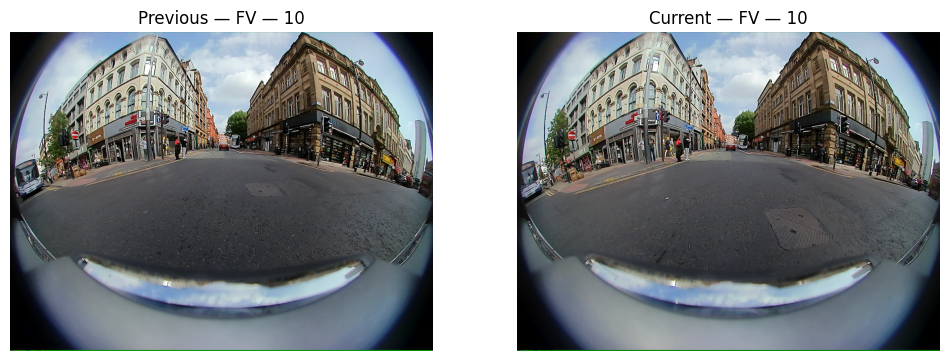

In [11]:
cam = "FV"
sample = pairs[cam][10]

prev_img = cv2.cvtColor(cv2.imread(str(sample["previous"])), cv2.COLOR_BGR2RGB)
curr_img = cv2.cvtColor(cv2.imread(str(sample["current"])), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(prev_img)
axes[0].set_title(f"Previous — {cam} — {sample['frame_id']}")
axes[0].axis("off")
axes[1].imshow(curr_img)
axes[1].set_title(f"Current — {cam} — {sample['frame_id']}")
axes[1].axis("off")
plt.show()

## 10. Create temporary MP4 adapters

The professor's `extract_features()` interface expects an MP4.

WoodScape supplies paired images, so these MP4s are only a temporary adapter for the existing professor pipeline.

In [12]:
def make_mp4(camera, which, n_frames):
    selected = [p[which] for p in pairs[camera][:n_frames]]

    first = cv2.imread(str(selected[0]))
    if first is None:
        raise RuntimeError(f"Cannot read {selected[0]}")

    h, w = first.shape[:2]
    out = CLIPS / f"woodscape_{camera}_{which}.mp4"

    writer = cv2.VideoWriter(
        str(out),
        cv2.VideoWriter_fourcc(*"mp4v"),
        10,
        (w, h),
    )

    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for {out}")

    for path in selected:
        frame = cv2.imread(str(path))
        if frame is None:
            raise RuntimeError(f"Cannot read {path}")
        writer.write(frame)

    writer.release()

    if not out.exists() or out.stat().st_size == 0:
        raise RuntimeError(f"Failed to create {out}")

    return out

for cam in CAMERAS:
    make_mp4(cam, "current", BASELINE_FRAMES)
    make_mp4(cam, "previous", BASELINE_FRAMES)
    print("Created clips:", cam)

Created clips: FV
Created clips: RV
Created clips: MVL
Created clips: MVR


# 11. DINOv2 smoke test

Expected:

- CLS = `(16, 384)`
- patch tokens = `(16, 2025, 384)`
- hidden states = layers `[3, 6, 9, 12]`

If this fails, stop before running the perception baseline.

In [13]:
from unified_perception.backbone import extract_features

test_clip = CLIPS / "woodscape_FV_current.mp4"

t0 = time.perf_counter()

with torch.no_grad():
    smoke = extract_features(
        str(test_clip),
        num_frames=BASELINE_FRAMES,
        model_name="vits14",
        device="cuda",
        image_size=IMAGE_SIZE,
        hidden_layer_indices=[3, 6, 9, 12],
        keep_frames=True,
    )

smoke_time = time.perf_counter() - t0

print("CLS shape:", tuple(smoke.cls.shape))
print("Patch shape:", tuple(smoke.patch_tokens.shape))
print("Hidden states:", sorted(smoke.hidden_states.keys()))
print("Runtime:", round(smoke_time, 3), "s")

assert tuple(smoke.cls.shape) == (BASELINE_FRAMES, 384)
assert tuple(smoke.patch_tokens.shape) == (BASELINE_FRAMES, 2025, 384)

print("DINOv2 ViT-S/14 smoke test passed.")

[backbone] Loading vits14 (facebook/dinov2-small) on cuda


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

CLS shape: (16, 384)
Patch shape: (16, 2025, 384)
Hidden states: [3, 6, 9, 12]
Runtime: 6.351 s
DINOv2 ViT-S/14 smoke test passed.


# 12. Run ONE baseline camera first — FV

This is the main validation step.

Do not run all four cameras until FV completes without the old YOLO unpacking error.

In [14]:
def run_baseline_camera(camera):
    clip = CLIPS / f"woodscape_{camera}_current.mp4"
    out_dir = RESULTS / f"baseline_{camera}"

    if out_dir.exists():
        shutil.rmtree(out_dir)

    cmd = [
        sys.executable,
        "-m", "unified_perception",
        "--source", str(clip),
        "--output-dir", str(out_dir),
        "--num-frames", str(BASELINE_FRAMES),
        "--model-name", "vits14",
        "--image-size", str(IMAGE_SIZE),
    ]

    env = os.environ.copy()
    env["SENTRY_DETECTION_MODE"] = "shared"
    env["PYTHONPATH"] = os.pathsep.join(
        [str(PROJECT), str(TRAINING_PACKAGE), str(TRAINING_SCRIPTS)]
        + [x for x in env.get("PYTHONPATH", "").split(os.pathsep) if x]
    )

    print("=" * 72)
    print("BASELINE:", camera)
    print("=" * 72)

    t0 = time.perf_counter()

    run = subprocess.run(
        cmd,
        cwd=PROJECT,
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    runtime = time.perf_counter() - t0

    print(run.stdout[-16000:])

    result_path = out_dir / "perception.json"

    return {
        "camera": camera,
        "return_code": run.returncode,
        "runtime_seconds": runtime,
        "output_dir": str(out_dir),
        "perception_json": str(result_path),
        "stdout_tail": run.stdout[-4000:],
        "json_exists": result_path.exists(),
    }

fv_result = run_baseline_camera("FV")
print(json.dumps(fv_result, indent=2))

if fv_result["return_code"] != 0:
    raise RuntimeError("FV baseline failed. Do not continue to all cameras.")

if not fv_result["json_exists"]:
    raise RuntimeError("FV succeeded but perception.json is missing.")

print("FV baseline completed.")

BASELINE: FV
0:00, 1290.36it/s, Materializing param=encoder.layer.8.norm1.weight]
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1932.50it/s, Materializing param=layernorm.weight]
[unified_perception] detection: frames=16 dets=177 [person=115, traffic light=25, car=24, bus=10, potted plant=2], conf=0.521
[unified_perception] action: primary=motorcycling, conf=0.526
{
  "action_summary": null,
  "grid_mp4": null,
  "combined_mp4": "/kaggle/working/woodscape_results_clean/baseline_FV/annotated_with_label.mp4",
  "heads": {
    "detection": {
      "summary": "frames=16 dets=177 [person=115, traffic light=25, car=24, bus=10, potted plant=2]",
      "confidence": 0.5209520236305568,
      "error": null
    },
    "action": {
      "summary": "primary=motorcycling",
      "confidence": 0.5258093476295471,
      "error": null
    }
  },
  "details_json": "/kaggle/working/woodscape_results_clean/baseline_FV/perception.json",
  "output_dir": "/kaggle/working/woodscape_results_clean/ba

## 13. Inspect FV perception output

The important checks are:

- no `ValueError: too many values to unpack`
- detection is not failing
- action output is present unless explicitly disabled

In [15]:
fv_json = Path(fv_result["perception_json"])
fv_data = json.loads(fv_json.read_text())

print(json.dumps(fv_data, indent=2)[:20000])

detection = fv_data.get("heads", {}).get("detection", {})
action = fv_data.get("heads", {}).get("action", {})

if detection.get("error"):
    raise RuntimeError(
        "FV shared detection still failed: "
        + str(detection.get("error"))
    )

if action.get("error"):
    print("WARNING: action head reported:", action.get("error"))

# Shared-mode primary is expected to be list-of-lists-of-dicts:
# one detection list per sampled frame.
primary = detection.get("primary")
num_detections = 0

if isinstance(primary, list):
    for frame_dets in primary:
        if isinstance(frame_dets, list):
            num_detections += len(frame_dets)

print("FV total detections across sampled frames:", num_detections)
assert num_detections > 0, "FV baseline returned zero detections."

print("✅ FV shared detection is working.")


{
  "source": "/kaggle/working/woodscape_clips_clean/woodscape_FV_current.mp4",
  "backbone": {
    "source": "/kaggle/working/woodscape_clips_clean/woodscape_FV_current.mp4",
    "model_name": "vits14",
    "hf_id": "facebook/dinov2-small",
    "num_frames": 16,
    "image_size": 640,
    "feature_dim": 384,
    "num_patches": 2025,
    "num_layers": 13,
    "fps": 10.0,
    "stride": 1
  },
  "heads": {
    "detection": {
      "head_name": "detection",
      "primary": [
        [
          {
            "bbox": [
              330.5164794921875,
              182.86965942382812,
              413.1517028808594,
              276.197509765625
            ],
            "conf": 0.9355923533439636,
            "class_id": 2,
            "class_name": "car"
          },
          {
            "bbox": [
              445.2734680175781,
              216.00267028808594,
              456.7470397949219,
              263.609619140625
            ],
            "conf": 0.741735577583313,


## 14. Run the remaining cameras

In [16]:
baseline_results = [fv_result]

for cam in ["RV", "MVL", "MVR"]:
    baseline_results.append(run_baseline_camera(cam))

baseline_df = pd.DataFrame(baseline_results)

display(
    baseline_df[
        ["camera", "return_code", "runtime_seconds", "json_exists"]
    ]
)

failed = baseline_df[baseline_df["return_code"] != 0]

if len(failed):
    print("Some cameras failed:")
    display(failed)

print(
    "Completed cameras:",
    list(baseline_df.loc[baseline_df.return_code == 0, "camera"])
)

BASELINE: RV
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1885.45it/s, Materializing param=layernorm.weight]
[unified_perception] detection: frames=16 dets=95 [car=77, person=14, traffic light=3, bus=1], conf=0.545
[unified_perception] action: primary=motorcycling, conf=0.266
{
  "action_summary": null,
  "grid_mp4": null,
  "combined_mp4": "/kaggle/working/woodscape_results_clean/baseline_RV/annotated_with_label.mp4",
  "heads": {
    "detection": {
      "summary": "frames=16 dets=95 [car=77, person=14, traffic light=3, bus=1]",
      "confidence": 0.5454912292105811,
      "error": null
    },
    "action": {
      "summary": "primary=motorcycling",
      "confidence": 0.26556065678596497,
      "error": null
    }
  },
  "details_json": "/kaggle/working/woodscape_results_clean/baseline_RV/perception.json",
  "output_dir": "/kaggle/working/woodscape_results_clean/baseline_RV"
}

BASELINE: MVL
███████▍  | 165/223 [00:00<00:00, 1378.76it/s, Materializing param=encoder.layer

,camera,return_code,runtime_seconds,json_exists
0,FV,0,20.786812,True
1,RV,0,16.873507,True
2,MVL,0,16.591142,True
3,MVR,0,16.750723,True


Completed cameras: ['FV', 'RV', 'MVL', 'MVR']


## 15. Extract compact detection/action summaries

In [17]:
def recursive_find(obj, keys):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k in keys:
                return v
            found = recursive_find(v, keys)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for item in obj:
            found = recursive_find(item, keys)
            if found is not None:
                return found
    return None

summary_rows = []

for cam in CAMERAS:
    path = RESULTS / f"baseline_{cam}" / "perception.json"
    if not path.exists():
        continue

    data = json.loads(path.read_text())

    runtime = next(
        (r["runtime_seconds"] for r in baseline_results if r["camera"] == cam),
        np.nan,
    )

    summary_rows.append({
        "camera": cam,
        "runtime_seconds": runtime,
        "detection": recursive_find(data, {"primary", "detections", "detection"}),
        "action": recursive_find(data, {"action", "action_label", "top_action", "label"}),
        "error": recursive_find(data, {"error", "errors"}),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

summary_df.to_csv(RESULTS / "baseline_summary.csv", index=False)

,camera,runtime_seconds,detection,action,error
0,FV,20.786812,"{'head_name': 'detection', 'primary': [[{'bbox...","{'head_name': 'action', 'primary': 'motorcycli...",None
1,RV,16.873507,"{'head_name': 'detection', 'primary': [[{'bbox...","{'head_name': 'action', 'primary': 'motorcycli...",None
2,MVL,16.591142,"{'head_name': 'detection', 'primary': [[{'bbox...","{'head_name': 'action', 'primary': 'busking', ...",None
3,MVR,16.750723,"{'head_name': 'detection', 'primary': [[{'bbox...","{'head_name': 'action', 'primary': 'driving ca...",None


# 16. Lightweight image-level temporal change

For each paired WoodScape image:

`change = mean(abs(current - previous))`

This is a lightweight candidate-selection signal. It is not yet used to skip DINOv2.

In [18]:
def image_change_score(previous_path, current_path):
    prev = cv2.imread(str(previous_path))
    curr = cv2.imread(str(current_path))

    if prev is None or curr is None:
        raise RuntimeError("Could not read paired images.")

    prev = cv2.resize(prev, (224, 224)).astype(np.float32) / 255.0
    curr = cv2.resize(curr, (224, 224)).astype(np.float32) / 255.0

    return float(np.abs(curr - prev).mean())

change_rows = []

for cam in CAMERAS:
    for p in pairs[cam][:PAIRS_PER_CAMERA]:
        change_rows.append({
            "camera": cam,
            "frame_id": p["frame_id"],
            "change_score": image_change_score(p["previous"], p["current"]),
        })

change_df = pd.DataFrame(change_rows)

display(change_df.head())
print("Mean change:", change_df.change_score.mean())
print("Median change:", change_df.change_score.median())

change_df.to_csv(RESULTS / "image_change_scores.csv", index=False)

,camera,frame_id,change_score
0,FV,0,0.075250
1,FV,1,0.077877
2,FV,2,0.057391
3,FV,3,0.066906
4,FV,4,0.050460


Mean change: 0.061039119616907556
Median change: 0.05960031412541866


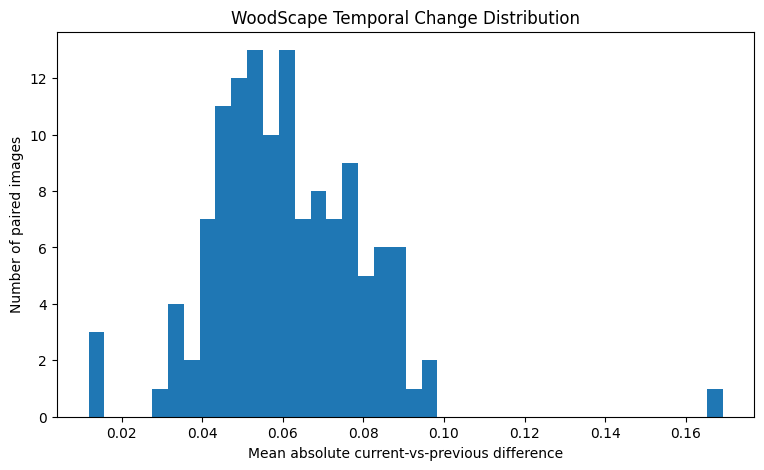

,change_score
0.25,0.049221
0.50,0.059600
0.75,0.073767
0.90,0.084339
0.95,0.088892
0.99,0.095051


In [19]:
plt.figure(figsize=(9, 5))
plt.hist(change_df["change_score"], bins=40)
plt.xlabel("Mean absolute current-vs-previous difference")
plt.ylabel("Number of paired images")
plt.title("WoodScape Temporal Change Distribution")
plt.show()

display(
    change_df["change_score"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("change_score")
)

# 17. DINOv2 patch-token temporal analysis

For corresponding current/previous frames:

`delta = ||current_patch - previous_patch||₂`

A small delta indicates a temporally stable representation and therefore a **candidate** for reuse.

This is potential reuse, not actual saved DINOv2 computation.

In [20]:
token_rows = []

for cam in CAMERAS:
    current_clip = CLIPS / f"woodscape_{cam}_current.mp4"
    previous_clip = CLIPS / f"woodscape_{cam}_previous.mp4"

    print("=" * 72)
    print("TOKEN ANALYSIS:", cam)
    print("=" * 72)

    t0 = time.perf_counter()

    with torch.no_grad():
        cur = extract_features(
            str(current_clip),
            num_frames=BASELINE_FRAMES,
            model_name="vits14",
            device="cuda",
            image_size=IMAGE_SIZE,
            hidden_layer_indices=[3, 6, 9, 12],
            keep_frames=False,
        )
        prev = extract_features(
            str(previous_clip),
            num_frames=BASELINE_FRAMES,
            model_name="vits14",
            device="cuda",
            image_size=IMAGE_SIZE,
            hidden_layer_indices=[3, 6, 9, 12],
            keep_frames=False,
        )

    elapsed = time.perf_counter() - t0

    delta = torch.norm(cur.patch_tokens - prev.patch_tokens, dim=-1).detach().cpu().numpy()
    flat = delta.reshape(-1)

    thresholds = {
        "p25": float(np.percentile(flat, 25)),
        "p50": float(np.percentile(flat, 50)),
        "p75": float(np.percentile(flat, 75)),
        "p90": float(np.percentile(flat, 90)),
        "p95": float(np.percentile(flat, 95)),
    }

    row = {
        "camera": cam,
        "analysis_runtime_seconds": elapsed,
        "mean_delta": float(flat.mean()),
        "median_delta": float(np.median(flat)),
        "max_delta": float(flat.max()),
        **thresholds,
    }

    for name, threshold in thresholds.items():
        row[f"potential_reuse_at_{name}_percent"] = float(
            (flat <= threshold).mean() * 100.0
        )

    token_rows.append(row)

    print("Patch tensor:", tuple(cur.patch_tokens.shape))
    print("Mean delta:", row["mean_delta"])
    print("Potential reuse at p50:", row["potential_reuse_at_p50_percent"], "%")

token_df = pd.DataFrame(token_rows)
display(token_df)

token_df.to_csv(RESULTS / "token_temporal_analysis.csv", index=False)

TOKEN ANALYSIS: FV
Patch tensor: (16, 2025, 384)
Mean delta: 21.17825698852539
Potential reuse at p50: 50.0 %
TOKEN ANALYSIS: RV
Patch tensor: (16, 2025, 384)
Mean delta: 16.07900047302246
Potential reuse at p50: 50.0 %
TOKEN ANALYSIS: MVL
Patch tensor: (16, 2025, 384)
Mean delta: 20.956823348999023
Potential reuse at p50: 50.0 %
TOKEN ANALYSIS: MVR
Patch tensor: (16, 2025, 384)
Mean delta: 17.501712799072266
Potential reuse at p50: 50.0 %


,camera,analysis_runtime_seconds,mean_delta,median_delta,max_delta,p25,p50,p75,p90,p95,potential_reuse_at_p25_percent,potential_reuse_at_p50_percent,potential_reuse_at_p75_percent,potential_reuse_at_p90_percent,potential_reuse_at_p95_percent
0,FV,3.183992,21.178257,16.380520,73.580269,9.789652,16.380520,29.774374,44.053295,50.403549,25.0,50.0,75.0,90.0,95.0
1,RV,3.110290,16.079000,11.152517,71.288857,6.393404,11.152517,21.776756,36.938778,45.165337,25.0,50.0,75.0,90.0,95.0
2,MVL,3.131009,20.956823,15.824833,68.347000,10.040577,15.824833,28.772282,44.144821,50.595417,25.0,50.0,75.0,90.0,95.0
3,MVR,3.199355,17.501713,13.024712,69.234993,8.116425,13.024712,23.341866,37.474163,45.362823,25.0,50.0,75.0,90.0,95.0


## 18. Per-frame potential reuse at the median threshold

The median threshold is used only as a descriptive experiment.

It does **not** mean half of DINOv2 can safely be skipped. The proper threshold for the research method should ultimately be selected using downstream detection/action fidelity.

In [21]:
per_frame_rows = []

for cam in CAMERAS:
    current_clip = CLIPS / f"woodscape_{cam}_current.mp4"
    previous_clip = CLIPS / f"woodscape_{cam}_previous.mp4"

    with torch.no_grad():
        cur = extract_features(
            str(current_clip),
            num_frames=BASELINE_FRAMES,
            model_name="vits14",
            device="cuda",
            image_size=IMAGE_SIZE,
            hidden_layer_indices=[3, 6, 9, 12],
            keep_frames=False,
        )
        prev = extract_features(
            str(previous_clip),
            num_frames=BASELINE_FRAMES,
            model_name="vits14",
            device="cuda",
            image_size=IMAGE_SIZE,
            hidden_layer_indices=[3, 6, 9, 12],
            keep_frames=False,
        )

    delta = torch.norm(cur.patch_tokens - prev.patch_tokens, dim=-1).detach().cpu().numpy()
    threshold = float(np.median(delta))

    for frame_idx in range(delta.shape[0]):
        stable = delta[frame_idx] <= threshold
        per_frame_rows.append({
            "camera": cam,
            "frame_index": frame_idx,
            "threshold": threshold,
            "potential_reuse_percent": float(stable.mean() * 100.0),
        })

per_frame_df = pd.DataFrame(per_frame_rows)

display(
    per_frame_df.groupby("camera")["potential_reuse_percent"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(3)
)

per_frame_df.to_csv(RESULTS / "per_frame_potential_reuse.csv", index=False)

,mean,median,std,min,max
camera,,,,,
FV,50.0,50.049,10.272,22.370,64.296
MVL,50.0,49.704,10.923,35.160,64.593
MVR,50.0,48.914,13.293,28.988,91.259
RV,50.0,52.000,5.941,39.012,61.037


## 19. Save the complete stage summary

In [22]:
final_summary = {
    "stage": "baseline_and_temporal_analysis",
    "dataset": "WoodScape",
    "cameras": CAMERAS,
    "baseline_frames": BASELINE_FRAMES,
    "pairs_per_camera": PAIRS_PER_CAMERA,
    "model": "DINOv2 ViT-S/14",
    "image_size": IMAGE_SIZE,
    "patch_grid": "45x45",
    "patch_tokens": 2025,
    "feature_dim": 384,
    "ultralytics_version": ultralytics.__version__,
    "yolo26_end2end_patch": True,
    "baseline": summary_df.to_dict(orient="records"),
    "token_analysis": token_df.to_dict(orient="records"),
}

summary_path = RESULTS / "stage_summary.json"
summary_path.write_text(json.dumps(final_summary, indent=2, default=str))

print("Saved:", summary_path)
print(json.dumps(final_summary, indent=2, default=str)[:30000])

Saved: /kaggle/working/woodscape_results_clean/stage_summary.json
{
  "stage": "baseline_and_temporal_analysis",
  "dataset": "WoodScape",
  "cameras": [
    "FV",
    "RV",
    "MVL",
    "MVR"
  ],
  "baseline_frames": 16,
  "pairs_per_camera": 32,
  "model": "DINOv2 ViT-S/14",
  "image_size": 640,
  "patch_grid": "45x45",
  "patch_tokens": 2025,
  "feature_dim": 384,
  "ultralytics_version": "8.4.152",
  "yolo26_end2end_patch": true,
  "baseline": [
    {
      "camera": "FV",
      "runtime_seconds": 20.786812485999917,
      "detection": {
        "head_name": "detection",
        "primary": [
          [
            {
              "bbox": [
                330.5164794921875,
                182.86965942382812,
                413.1517028808594,
                276.197509765625
              ],
              "conf": 0.9355923533439636,
              "class_id": 2,
              "class_name": "car"
            },
            {
              "bbox": [
                445.2734680175

In [23]:
import shutil

shutil.make_archive(
    "/kaggle/working/kaggle_working",
    "zip",
    "/kaggle/working"
)

print("Created: /kaggle/working/kaggle_working.zip")

Created: /kaggle/working/kaggle_working.zip


# 20. What this notebook establishes

## Baseline

- WoodScape current/previous pairs are identified.
- Professor's `UnifiedPerception` package runs from a writable Kaggle copy.
- DINOv2 ViT-S/14 is verified at 640×640.
- Shared detection + action pipeline is executed.
- YOLO26 compatibility is handled in both the professor runner and the shared-feature detection path without changing DINOv2.

## Temporal analysis

- image-level current/previous change is measured.
- DINOv2 patch-token deltas are measured.
- potential stable-token percentages are measured per camera/frame.

## What is NOT claimed

The token-delta experiment does **not** mean DINOv2 actually performed fewer FLOPs.

## Next research stage

Modify transformer execution itself:

`previous intermediate token states → detect stable tokens → reuse/cache stable representations → compute only changed tokens`

Then compare:

- baseline latency
- actual DINOv2 compute
- token reuse ratio
- detection performance
- action-recognition performance
- end-to-end latency